In [39]:
#Nulláról
import pandas as pd
import glob
import os

base_folder = r"C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok"
years = ["2022", "2023", "2024", "2025"]

dfs = []

pattern = r'^\d{4}-'

for year in years:
    folder_path = os.path.join(base_folder, year)
    file_list = glob.glob(os.path.join(folder_path, "*.xlsx"))
    print(f"{year}: {len(file_list)} fájl található")

    for file in file_list:
        print("Beolvasás:", file)
        temp_df = pd.read_excel(file)
        temp_df["year"] = int(year)

        mask = (
            temp_df['start_place_id'].astype(str).str.match(pattern) &
            temp_df['end_place_id'].astype(str).str.match(pattern)
        )
        temp_df = temp_df[mask]

        cols = ['start_time', 'end_time', 'duration', 'start_place_id', 'end_place_id',
                'start_lat', 'start_lng', 'end_lat', 'end_lng',
                'cust_id', 'bike_id', 'coupon_name', 'year']
        temp_df = temp_df[cols]

        dfs.append(temp_df)

#Összefűzés
df = pd.concat(dfs, ignore_index=True)
print("Összes sor beolvasva és szűrve:", len(df))

df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
df = df.dropna(subset=['start_time', 'end_time'])

#Időtartam percben
df['duration_min'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60
df = df[(df['duration_min'] > 0) & (df['duration_min'] < 120)]

df.to_pickle("bubi_all_years.pkl")

2022: 12 fájl található
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_01.xlsx
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_02.xlsx
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_03.xlsx
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_04.xlsx
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_05.xlsx
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_06.xlsx
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_07.xlsx
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_08.xlsx
Beolvasás: C:\Users\lzscs\Desktop\Témalabor1\Bubi-data-analyzis---T-malabor1\Code\Adatok\2022\2022_09.xlsx
Beolvasás: C:

In [1]:
import pandas as pd
df = pd.read_pickle("bubi_all_years.pkl")

Utazások száma: 11081141
Átlagos utazási idő (perc): 12.49
Medián utazási idő (perc): 10.43

Óránkénti utazások száma:
hour
0      244723
1      144201
2       91722
3       63165
4       47788
5       58537
6      151972
7      435693
8      617310
9      487453
10     400293
11     473740
12     546470
13     573733
14     587807
15     675667
16     862574
17    1040131
18     932855
19     790242
20     643488
21     484622
22     403946
23     323009
dtype: int64

Hónaponkénti utazások száma (évenként):
year  month
2022  1         66988
      2         89988
      3        137460
      4        161222
      5        313564
      6        327840
      7        296614
      8        329689
      9        321085
      10       309626
      11       189771
      12       110605
2023  1        110601
      2        115899
      3        193540
      4        233756
      5        332697
      6        353461
      7        338981
      8        347748
      9        407358
      10    

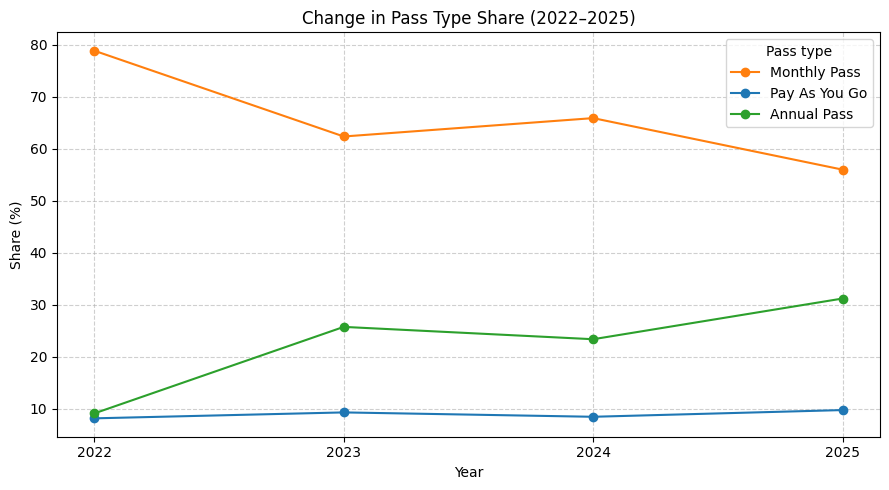

In [7]:
# Statisztikák
print("Utazások száma:", len(df))
print("Átlagos utazási idő (perc):", df['duration_min'].mean().round(2))
print("Medián utazási idő (perc):", df['duration_min'].median().round(2))

df['hour'] = df['start_time'].dt.hour
traffic_by_hour = df.groupby('hour').size()
print("\nÓránkénti utazások száma:")
print(traffic_by_hour)

df['month'] = df['start_time'].dt.month
traffic_by_month = df.groupby(['year', 'month']).size()
print("\nHónaponkénti utazások száma (évenként):")
print(traffic_by_month)

#Legforgalmasabb állomások:
start_counts = df.groupby('start_place_id').size().reset_index(name='indulások')
end_counts = df.groupby('end_place_id').size().reset_index(name='érkezések')

station_traffic = pd.merge(start_counts, end_counts,
                           left_on='start_place_id', right_on='end_place_id',
                           how='outer')

station_traffic['állomás'] = station_traffic['start_place_id'].combine_first(station_traffic['end_place_id'])
station_traffic['összes_forgalom'] = station_traffic['indulások'].fillna(0) + station_traffic['érkezések'].fillna(0)

top_stations = station_traffic.sort_values('összes_forgalom', ascending=False).head(10)
print(top_stations[['állomás', 'összes_forgalom']])

# Bérlettípusok aránya évenként
license_share = df.groupby(['year', 'coupon_name']).size().reset_index(name='trips')
license_share['share (%)'] = (
    license_share['trips'] /
    license_share.groupby('year')['trips'].transform('sum') * 100
).round(2)

import matplotlib.pyplot as plt

name_map = {
    'Havi bérlet': 'Monthly Pass',
    'Éves bérlet': 'Annual Pass',
    'PAYG': 'Pay As You Go'
}
license_share['coupon_name'] = license_share['coupon_name'].replace(name_map)

top3 = (
    license_share.groupby('coupon_name')['trips']
    .sum()
    .nlargest(3)
    .index
)
top3_df = license_share[license_share['coupon_name'].isin(top3)]

plt.figure(figsize=(9, 5))

colors = {
    'Pay As You Go': '#1f77b4',
    'Monthly Pass': '#ff7f0e',
    'Annual Pass': '#2ca02c'
}

for name in top3_df['coupon_name'].unique():
    subset = top3_df[top3_df['coupon_name'] == name].copy()
    subset['year'] = subset['year'].astype(int)  # konvertálás int-re
    plt.plot(
        subset['year'],
        subset['share (%)'],  # itt a helyes oszlopnév
        marker='o',
        label=name,
        color=colors.get(name)
    )

plt.title("Change in Pass Type Share (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.xticks([2022, 2023, 2024, 2025])  # csak kerek évek
plt.legend(title="Pass type")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Állomások forgalma
import folium

station_coords = df.groupby('start_place_id')[['start_lat', 'start_lng']].mean().reset_index()
station_coords.rename(columns={'start_place_id': 'állomás'}, inplace=True)

station_map_data = pd.merge(station_coords, station_traffic, on='állomás', how='left')

m = folium.Map(location=[47.4979, 19.0402], zoom_start=12)

for _, row in station_map_data.iterrows():
    folium.CircleMarker(
        location=[row['start_lat'], row['start_lng']],
        radius=row['összes_forgalom'] / 100000,  
        color='blue',
        fill=True,
        fill_opacity=0.5,
        popup=f"{row['állomás']} – {int(row['összes_forgalom'])} utazás"
    ).add_to(m)

m.save("bubi_allomasok_forgalma.html")

In [10]:
#felhasználói viselkedes
import pandas as pd

station_groups = [
    {
        "name": "Csonka János Square",
        "station_ids": ["1128-Csonka János tér"],
        "open": "2022-06-15"
    },
    {
        "name": "Zugló Group",
        "station_ids": [
            "1406-Egressy út - Stefánia út",
            "1407-Stefánia út - Thököly út",
            "1408-Zugló vasútállomás",
            "1409-Kacsóh Pongrác út",
            "1410-Papp László Budapest Sportaréna",
            "1411-Reiner Frigyes park"
        ],
        "open": "2023-06-28"
    },
    {
        "name": "District 9 Stations",
        "station_ids": [
            "0921-Mester utca - Ferenc körút",
            "0922-Haller utca – Mester utca",
            "0923-Nádasdy utca (játszótér)",
            "0924-Haller utca - Soroksári út"
        ],
        "open": "2023-09-01"
    },
    {
        "name": "Kopaszi-gát",
        "station_ids": ["1137-Kopaszi-gát"],
        "open": "2024-04-09"
    },
    {
        "name": "Westend – Balzac Street",
        "station_ids": ["0620-Westend - Balzac utca"],
        "open": "2024-05-01"
    }
]

results = []

for group in station_groups:
    group_name = group["name"]
    station_ids = group["station_ids"]
    open_date = pd.to_datetime(group["open"])

    before_start = open_date - pd.Timedelta(days=90)
    after_end = open_date + pd.Timedelta(days=90)

    users_after_group = set(
        df[
            ((df['start_place_id'].isin(station_ids)) | (df['end_place_id'].isin(station_ids))) &
            (df['start_time'].between(open_date, after_end))
        ]['cust_id']
    )

    users_before_system = set(
        df[
            df['start_time'].between(before_start, open_date)
        ]['cust_id']
    )

    new_users = users_after_group - users_before_system
    migrated_users = users_after_group & users_before_system

    total_after = len(users_after_group)
    new_ratio = (len(new_users) / total_after * 100) if total_after > 0 else 0
    migrated_ratio = (len(migrated_users) / total_after * 100) if total_after > 0 else 0

    results.append({
        "Station Group": group_name,
        "Opening Date": group["open"],
        "New Users": len(new_users),
        "Migrated Users": len(migrated_users),
        "Total (After Opening)": total_after,
        "New User Share (%)": round(new_ratio, 1),
        "Migrated User Share (%)": round(migrated_ratio, 1)
    })

result_df = pd.DataFrame(results)
print("New and Migrated Users by Station Group:\n")
print(result_df)


📊 New and Migrated Users by Station Group:

             Station Group Opening Date  New Users  Migrated Users  \
0      Csonka János Square   2022-06-15        371             763   
1              Zugló Group   2023-06-28       1849            3348   
2      District 9 Stations   2023-09-01        770            2349   
3              Kopaszi-gát   2024-04-09       1370            1698   
4  Westend – Balzac Street   2024-05-01        553            1312   

   Total (After Opening)  New User Share (%)  Migrated User Share (%)  
0                   1134                32.7                     67.3  
1                   5197                35.6                     64.4  
2                   3119                24.7                     75.3  
3                   3068                44.7                     55.3  
4                   1865                29.7                     70.3  


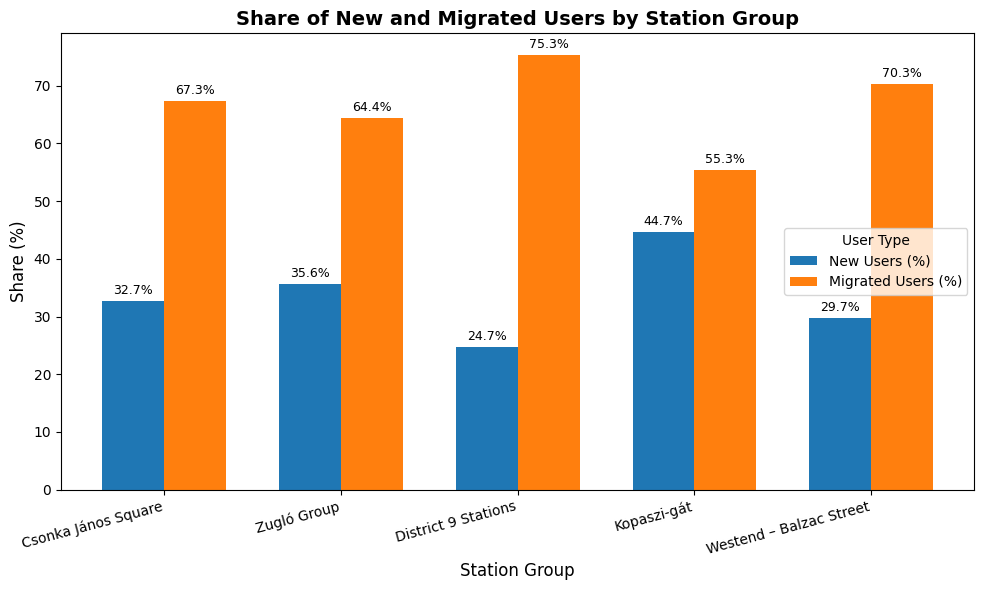

In [11]:
import matplotlib.pyplot as plt
import numpy as np

groups = result_df['Station Group']
new_ratio = result_df['New User Share (%)']
migrated_ratio = result_df['Migrated User Share (%)']

x = np.arange(len(groups))
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, new_ratio, width, label='New Users (%)', color='#1f77b4')
bars2 = ax.bar(x + width/2, migrated_ratio, width, label='Migrated Users (%)', color='#ff7f0e')

ax.set_title('Share of New and Migrated Users by Station Group', fontsize=14, weight='bold')
ax.set_xlabel('Station Group', fontsize=12)
ax.set_ylabel('Share (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=15, ha='right')
ax.legend(title='User Type')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



C:\Users\lzscs\AppData\Local\Temp\ipykernel_12028\708017830.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[866.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  plot_df.loc[


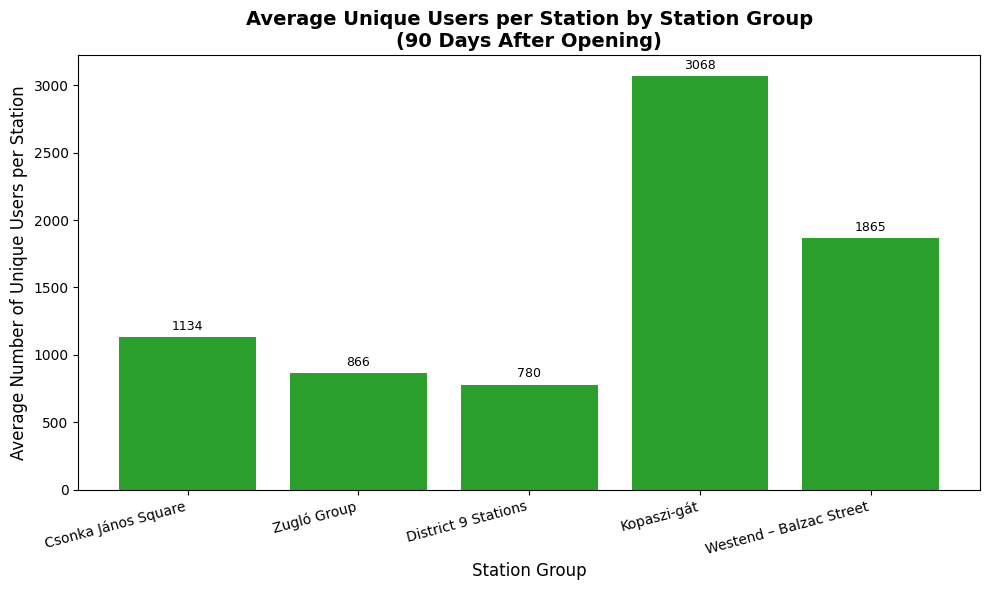

In [12]:
# másik ábra: felhasználók száma az új állomásokon a bevezetést követő 90 napban
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = result_df.copy()

station_counts = {
    'Zugló Group': 6,
    'District 9 Stations': 4
}

for group, count in station_counts.items():
    plot_df.loc[
        plot_df['Station Group'] == group,
        'Total (After Opening)'
    ] = (
        plot_df.loc[
            plot_df['Station Group'] == group,
            'Total (After Opening)'
        ] / count
    )

x = np.arange(len(plot_df))
bars = ax.bar(x, plot_df['Total (After Opening)'], color='#2ca02c')

ax.set_title(
    'Average Unique Users per Station by Station Group\n(90 Days After Opening)',
    fontsize=14, weight='bold'
)
ax.set_xlabel('Station Group', fontsize=12)
ax.set_ylabel('Average Number of Unique Users per Station', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Station Group'], rotation=15, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{int(round(height))}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()



             Station Group Opening Date  New Users  Migrated Users  \
0      Csonka János Square   2022-06-15        371             763   
1              Zugló Group   2023-06-28       1849            3348   
2      District 9 Stations   2023-09-01        770            2349   
3              Kopaszi-gát   2024-04-09       1370            1698   
4  Westend – Balzac Street   2024-05-01        553            1312   

   Avg Trips/Month/New  Avg Trips/Month/Migrated  Avg Trip Length/New  \
0             1.202156                  1.520315            12.948518   
1             1.569497                  1.708284            15.991565   
2             1.624675                  1.495814            12.123985   
3             0.866180                  0.916372            17.136540   
4             0.692586                  0.765498            13.953525   

   Avg Trip Length/Migrated  Churn/New (%)  Churn/Migrated (%)  
0                 12.548855      30.997305           15.072084  
1         

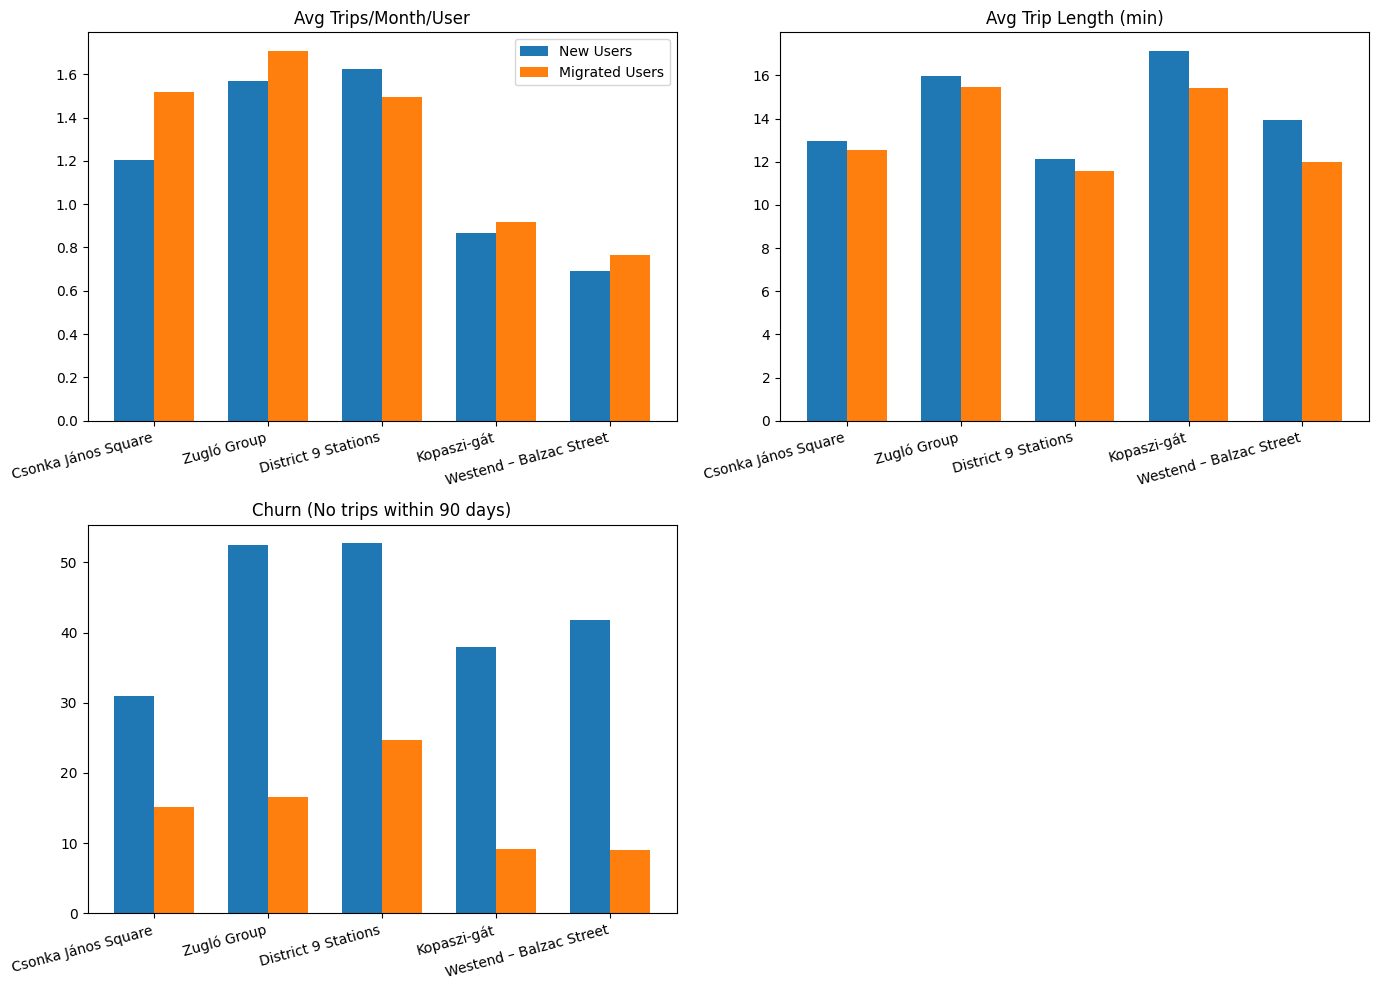

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

station_groups = [
    {"name": "Csonka János Square", "station_ids": ["1128-Csonka János tér"], "open": "2022-06-15"},
    {"name": "Zugló Group", "station_ids": [
        "1406-Egressy út - Stefánia út", "1407-Stefánia út - Thököly út",
        "1408-Zugló vasútállomás", "1409-Kacsóh Pongrác út",
        "1410-Papp László Budapest Sportaréna", "1411-Reiner Frigyes park"], "open": "2023-06-28"},
    {"name": "District 9 Stations", "station_ids": [
        "0921-Mester utca - Ferenc körút", "0922-Haller utca – Mester utca",
        "0923-Nádasdy utca (játszótér)", "0924-Haller utca - Soroksári út"], "open": "2023-09-01"},
    {"name": "Kopaszi-gát", "station_ids": ["1137-Kopaszi-gát"], "open": "2024-04-09"},
    {"name": "Westend – Balzac Street", "station_ids": ["0620-Westend - Balzac utca"], "open": "2024-05-01"}
]

results = []

for group in station_groups:
    group_name = group["name"]
    station_ids = group["station_ids"]
    open_date = pd.to_datetime(group["open"])
    
    before_start = open_date - pd.Timedelta(days=90)
    after_end = open_date + pd.Timedelta(days=90)
    
    df_after = df[
        ((df['start_place_id'].isin(station_ids)) | (df['end_place_id'].isin(station_ids))) &
        (df['start_time'].between(open_date, after_end))
    ].copy()
    
    users_after_group = set(df_after['cust_id'])
    users_before_system = set(df[df['start_time'].between(before_start, open_date)]['cust_id'])
    
    new_users = users_after_group - users_before_system
    migrated_users = users_after_group & users_before_system
    
    def usage_freq(user_set):
        df_user = df_after[df_after['cust_id'].isin(user_set)]
        days = (after_end - open_date).days
        trips_per_month = df_user.groupby('cust_id').size() / (days/30)
        return trips_per_month
    
    freq_new = usage_freq(new_users)
    freq_migrated = usage_freq(migrated_users)
    
    trip_len_new = df_after[df_after['cust_id'].isin(new_users)]['duration_min']
    trip_len_migrated = df_after[df_after['cust_id'].isin(migrated_users)]['duration_min']
    
    after_end_churn = after_end + pd.Timedelta(days=90)
    df_after_90 = df[(df['start_time'] > after_end) & (df['start_time'] <= after_end_churn)]
    user_trip_counts = df_after_90.groupby('cust_id').size()
    
    if len(new_users) > 0:
        churn_new = 100 * sum(~pd.Series(list(new_users)).isin(user_trip_counts.index)) / len(new_users)
    else:
        churn_new = 0

    if len(migrated_users) > 0:
        churn_migrated = 100 * sum(~pd.Series(list(migrated_users)).isin(user_trip_counts.index)) / len(migrated_users)
    else:
        churn_migrated = 0
    
    results.append({
        "Station Group": group_name,
        "Opening Date": group["open"],
        "New Users": len(new_users),
        "Migrated Users": len(migrated_users),
        "Avg Trips/Month/New": freq_new.mean() if len(freq_new) > 0 else 0,
        "Avg Trips/Month/Migrated": freq_migrated.mean() if len(freq_migrated) > 0 else 0,
        "Avg Trip Length/New": trip_len_new.mean() if len(trip_len_new) > 0 else 0,
        "Avg Trip Length/Migrated": trip_len_migrated.mean() if len(trip_len_migrated) > 0 else 0,
        "Churn/New (%)": churn_new,
        "Churn/Migrated (%)": churn_migrated
    })

df_summary = pd.DataFrame(results)
print(df_summary)

fig, axes = plt.subplots(2, 2, figsize=(14,10))
x = np.arange(len(df_summary))
width = 0.35

axes[0,0].bar(x - width/2, df_summary['Avg Trips/Month/New'], width, label='New Users', color='#1f77b4')
axes[0,0].bar(x + width/2, df_summary['Avg Trips/Month/Migrated'], width, label='Migrated Users', color='#ff7f0e')
axes[0,0].set_title('Avg Trips/Month/User')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(df_summary['Station Group'], rotation=15, ha='right')
axes[0,0].legend()

axes[0,1].bar(x - width/2, df_summary['Avg Trip Length/New'], width, label='New Users', color='#1f77b4')
axes[0,1].bar(x + width/2, df_summary['Avg Trip Length/Migrated'], width, label='Migrated Users', color='#ff7f0e')
axes[0,1].set_title('Avg Trip Length (min)')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(df_summary['Station Group'], rotation=15, ha='right')

axes[1,0].bar(x - width/2, df_summary['Churn/New (%)'], width, label='New Users', color='#1f77b4')
axes[1,0].bar(x + width/2, df_summary['Churn/Migrated (%)'], width, label='Migrated Users', color='#ff7f0e')
axes[1,0].set_title('Churn (No trips within 90 days)')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(df_summary['Station Group'], rotation=15, ha='right')

axes[1,1].axis('off')

plt.tight_layout()
plt.show()


In [29]:
print(df.columns)


Index(['start_time', 'end_time', 'duration', 'start_place_id', 'end_place_id',
       'start_lat', 'start_lng', 'end_lat', 'end_lng', 'cust_id', 'bike_id',
       'coupon_name', 'year', 'duration_min', 'hour', 'month'],
      dtype='object')


In [2]:
#Hőtérképek egyben
import folium
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.cm as cm


def station_traffic(data):
    """Összesíti az állomások forgalmát (indulás + érkezés)."""
    start_counts = data.groupby(['start_place_id', 'start_lat', 'start_lng']).size().reset_index(name='count')
    start_counts.rename(columns={'start_place_id': 'station_id', 'start_lat': 'lat', 'start_lng': 'lng'}, inplace=True)

    end_counts = data.groupby(['end_place_id', 'end_lat', 'end_lng']).size().reset_index(name='count')
    end_counts.rename(columns={'end_place_id': 'station_id', 'end_lat': 'lat', 'end_lng': 'lng'}, inplace=True)

    traffic = pd.concat([start_counts, end_counts])
    traffic = (
        traffic.groupby('station_id')
        .agg({'count': 'sum', 'lat': 'mean', 'lng': 'mean'})
        .reset_index()
    )
    return traffic


def color_by_traffic(count, cmap, min_count, max_count):
    """Forgalom alapján visszaad egy hex színt."""
    norm = mcolors.Normalize(vmin=min_count, vmax=max_count)
    rgb = cmap(norm(count))[:3]
    return mcolors.to_hex(rgb)


def generate_maps(stations, open_date_str, filename_prefix, df):
    """Elkészíti a 'before' és 'after' forgalmi térképeket az adott állomáscsoporthoz."""
    open_date = pd.to_datetime(open_date_str)
    
    # --- Időszakok definiálása ---
    before_period = (df['start_time'] >= open_date - pd.Timedelta(days=90)) & (df['start_time'] < open_date)
    after_period = (df['start_time'] >= open_date) & (df['start_time'] < open_date + pd.Timedelta(days=90))

    # --- Forgalmi adatok számítása ---
    before_traffic = station_traffic(df[before_period])
    after_traffic = station_traffic(df[after_period])

    # --- Színskálák és normalizálás ---
    warm_colormap = cm.get_cmap('YlOrRd')   # sárga→piros (meglévő)
    cool_colormap = cm.get_cmap('winter')   # kék→zöld (új állomás)
    min_count = min(before_traffic['count'].min(), after_traffic['count'].min())
    max_count = max(before_traffic['count'].max(), after_traffic['count'].max())

    # --- Térkép középpont ---
    coords = df[df['end_place_id'].isin(stations)][['end_lat', 'end_lng']].dropna()
    center_lat = coords['end_lat'].mean()
    center_lng = coords['end_lng'].mean()

    # --- "Before" térkép ---
    m_before = folium.Map(location=[center_lat, center_lng], zoom_start=13, tiles="CartoDB positron")
    for _, row in before_traffic.iterrows():
        color = color_by_traffic(row['count'], warm_colormap, min_count, max_count)
        folium.CircleMarker(
            location=[row['lat'], row['lng']],
            radius=2 + row['count'] / 500,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=f"{row['station_id']}: {row['count']} trips (before)"
        ).add_to(m_before)
    m_before.save(f"{filename_prefix}_before_traffic.html")

    # --- "After" térkép ---
    m_after = folium.Map(location=[center_lat, center_lng], zoom_start=13, tiles="CartoDB positron")
    for _, row in after_traffic.iterrows():
        if row['station_id'] in stations:
            color = color_by_traffic(row['count'], cool_colormap, min_count, max_count)
        else:
            color = color_by_traffic(row['count'], warm_colormap, min_count, max_count)
        folium.CircleMarker(
            location=[row['lat'], row['lng']],
            radius=2 + row['count'] / 500,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=f"{row['station_id']}: {row['count']} trips (after)"
        ).add_to(m_after)
    m_after.save(f"{filename_prefix}_after_traffic.html")

    print(f"  • {filename_prefix}_before_traffic.html")
    print(f"  • {filename_prefix}_after_traffic.html\n")



generate_maps(
    stations=["1406-Egressy út - Stefánia út", "1407-Stefánia út - Thököly út",
              "1408-Zugló vasútállomás", "1409-Kacsóh Pongrác út",
              "1410-Papp László Budapest Sportaréna", "1411-Reiner Frigyes park"],
    open_date_str="2023-06-28",
    filename_prefix="zuglo",
    df=df
)

generate_maps(
    stations=["0921-Mester utca - Ferenc körút", "0922-Haller utca – Mester utca",
              "0923-Nádasdy utca (játszótér)", "0924-Haller utca - Soroksári út"],
    open_date_str="2023-09-01",
    filename_prefix="kerulet9",
    df=df
)

generate_maps(
    stations=["1137-Kopaszi-gát"],
    open_date_str="2024-04-09",
    filename_prefix="kopaszi",
    df=df
)

generate_maps(
    stations=["0620-Westend - Balzac utca"],
    open_date_str="2024-05-01",
    filename_prefix="westend",
    df=df
)

generate_maps(
    stations=["1128-Csonka János tér"],
    open_date_str="2022-06-15",
    filename_prefix="csonka",
    df=df
)

C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  warm_colormap = cm.get_cmap('YlOrRd')   # sárga→piros (meglévő)
C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cool_colormap = cm.get_cmap('winter')   # kék→zöld (új állomás)


  • zuglo_before_traffic.html
  • zuglo_after_traffic.html



C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  warm_colormap = cm.get_cmap('YlOrRd')   # sárga→piros (meglévő)
C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cool_colormap = cm.get_cmap('winter')   # kék→zöld (új állomás)


  • kerulet9_before_traffic.html
  • kerulet9_after_traffic.html



C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  warm_colormap = cm.get_cmap('YlOrRd')   # sárga→piros (meglévő)
C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cool_colormap = cm.get_cmap('winter')   # kék→zöld (új állomás)


  • kopaszi_before_traffic.html
  • kopaszi_after_traffic.html



C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  warm_colormap = cm.get_cmap('YlOrRd')   # sárga→piros (meglévő)
C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cool_colormap = cm.get_cmap('winter')   # kék→zöld (új állomás)


  • westend_before_traffic.html
  • westend_after_traffic.html



C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  warm_colormap = cm.get_cmap('YlOrRd')   # sárga→piros (meglévő)
C:\Users\lzscs\AppData\Local\Temp\ipykernel_20276\2231725257.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cool_colormap = cm.get_cmap('winter')   # kék→zöld (új állomás)


  • csonka_before_traffic.html
  • csonka_after_traffic.html

